# Principal components analysis

Suppose we conduct an experiment $n$ times and collect $p$ pieces of information from each experiment. Then we can suppose that we collected a dataset $\mathcal{D} = \{ (x_{11},x_{12},\cdots, x_{1p} ), (x_{21},x_{22},\cdots, x_{2p} ),  \cdots, (x_{n1},x_{n2},\cdots, x_{np} )  \}$ and can organize this dataset into the following dataframe 

\begin{align}
    \mathcal{F} = \begin{bmatrix}
        x_{11} & x_{12} & \cdots & x_{1p}\\
        x_{21} & x_{22} & \cdots & x_{2p}\\
        \vdots & \vdots & \vdots & \ddots \\
        x_{n1} & x_{n2} & \cdots & x_{np}\\
        \end{bmatrix}
\end{align}

It is important to acknowledge that a single observation is the tuple $(x_{i1} \cdots x_{1p})$ and so we assume that a tuple of random variables *jointly* generated this single observation. 
In other words, it may not be appropriate to treat each piece of information (often called a covariate) as being generated independently of other covariates: they are generated together.   

The goal of principal components analysis is to find combinations of covariates that "best" describe our original dataset $\mathcal{D}$. 

In this lesson we will aim to understand:
1. How principal components defines "best"
2. The interplay between the (linear) algebra and geometry of principal components
3. How to interpret the outputs of out principal components analysis
4. How principal components analysis differs from linear regression 

## Simulated data 

We will first build a simulated dataset to illustrate the main concepts in principal components analysis. Let the random variables $[X_{1}, X_{2}]$ have a multivariate normal distribution (MVN)

\begin{align}
    &\begin{bmatrix}
        X_{1} \\ 
        X_{2}
    \end{bmatrix} \sim \text{MVN}( \mu, \Sigma ) \\ 
    & \mu    = \begin{bmatrix} -1 \\ 1 \end{bmatrix} ; \; 
    \Sigma  = \begin{bmatrix} 1 & 0.3 \\ 0.3 & 2 \end{bmatrix}
\end{align}

As a recap, the vector $\mu$ decribes the expected value for $X_{1}$ (the value -1) and the expected value for $X_{2}$ (the value 1). 
The *covariance matrix* $\Sigma$ describes the variance for $X_{1}$ (the value 1), the variance for $X_{2}$ (the value 2), and the covariance between $X_{1}$ and $X_{2}$ (the value 0.3).  

We can use `numpy` to  help use generate $n=100$ observations from the above MVN where every observation contains two pieces of information (i.e. two covariates). 
In addition to storing our dataset, we will visualize this information by scatterplotting values of the first covariate versus values of the second covariate. 

### Plotting and centering our data 

Below, you will see two plots side-by-side. 
The first plot includes the scatter (blue circles) as well as a vertical and horizontal line at the values 0 (dashed blue lines). 
Though we typically draw the horizontal and vertical axes for a plot at 0, the value zero is 
arbitrary.
A more reasonable place to draw our axes may be the expected values for the first (-1) and second (1) covariate. We drew those axes as solid blue lines.  

The solid blue lines (expected values) look to be better centered over our dataset than the dashed lines (zeros). 

The above is the motivation behind **centering**. 
Instead of plotting our raw data $\mathcal{D} = \{ (x_{11}, x_{12}),(x_{21}, x_{22}),\cdots, (x_{n1}, x_{n2})  \}$ we can plot a centered dataset that describes the distance of each observation from their expected value or $(x_{i1} - \mu_{1}, x_{i2}-\mu_{2})$ for all $i$ observations. 
Another way to look at this is with our dataframe

\begin{align}
    \underset{-}{\mathcal{F}} = \begin{bmatrix}
        x_{11} - \mu_{1} & x_{12} - \mu_{2} \\
        x_{21} - \mu_{1} & x_{22} - \mu_{2} \\
        \vdots & \vdots \\
        x_{n1}- \mu_{1} & x_{n2} - \mu_{2} \\
        \end{bmatrix} = \mathcal{F}_{n \times 2} - \mu_{1 \times 2} 
\end{align}

Importantly, the original dataset describes the distance of each covariate from the (arbitrary) value zero. In other words, 

\begin{align}
    \mathcal{F} = \begin{bmatrix}
        x_{11}  & x_{12}  \\
        x_{21}  & x_{22}  \\
        \vdots & \vdots \\
        x_{n1} & x_{n2}  \\
        \end{bmatrix} =  \begin{bmatrix}
        x_{11} - 0 & x_{12} - 0 \\
        x_{21} - 0 & x_{22} - 0 \\
        \vdots & \vdots \\
        x_{n1}- 0 & x_{n2} - 0 \\
        \end{bmatrix} = \mathcal{F}_{n \times 2} - 0_{1 \times 2} 
\end{align}

The rightmost panel in our figure below plots the centered dataset (solid blue circles) as well as vertical and horizontal axes at zero. 
The reason that these horizonal/vertical lines at zero are centered over the data now is because the value zero for our *centered* dataset represents the expected value. 
For example, the $i^{\text{th}}$ observation is $(x_{1}= x_{i1}-\mu_{1}, x_{2} = x_{i1}-\mu_{2} )$. When $x_{1}=0$ then $x_{i1}-\mu_{1}=0$ or $x_{i1}=\mu_{1}$.
The same argument could be used for the second covariate as well. 
The centered datset describes *the distance from each covariate's expected value*. 

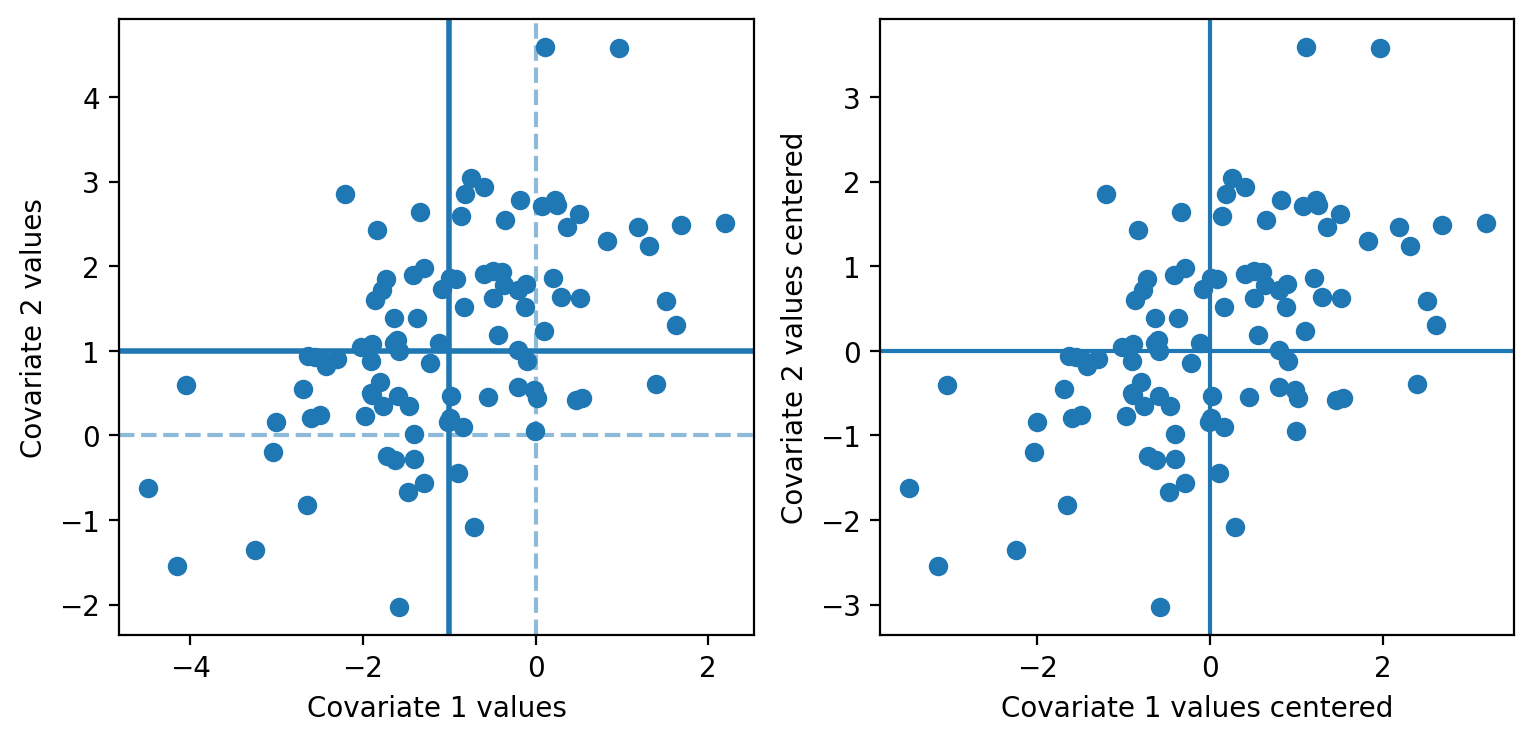

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

#--Specify the MVN expected value M and the covariance COV
#--Generate 100 observations from this vector of random variables  
M   = np.array([-1,1]) 
COV = np.array([[ 1, 0.6 ], [0.6 , 2]])

#--Note: these three lines are not important to know. 
#--You can just assume that this is the process by which we generate MVN observations. 
L   = np.linalg.cholesky(COV)
z   = np.random.normal( 0,1 ,size = (100,2) )
d   = M + z@L


#--Visualize this dataset 
fig,axs = plt.subplots(1,2)

#--non-centered dataset
ax=axs[0]
ax.scatter(d[:,0], d[:,1])

ax.axhline(0, alpha=0.5, ls="--")
ax.axvline(0, alpha=0.5, ls="--")

ax.axhline(1,lw=2)
ax.axvline(-1,lw=2)

ax.set_xlabel("Covariate 1 values")
ax.set_ylabel("Covariate 2 values")

#--centered dataset
d_centered = d - M #<--subtract the expected value from each covariate

ax=axs[1]

ax.scatter(d_centered[:,0], d_centered[:,1])

ax.axhline(0)
ax.axvline(0)

ax.set_xlabel("Covariate 1 values centered")
ax.set_ylabel("Covariate 2 values centered")

fig.set_size_inches(9,4)

plt.show()

## Geometric intuition behind Principal Components Analysis

Centering our dataset (right panel above) helped us more naturally descirbe our dataset. 
The zero horizonal/vertical values now correspond to the expected value for the first/second covariate. 
However, centering only allows us to **shift** our axes up/down and left/right to better decribe our data. 
What about rotation?

Geometrically, Principal Components Analysis asks "Can we rotate our axes to better characterize our dataset?". Well, if we are willing to consider rotating our axes then we need to decide on what we mean when say better. 

Lets start with just the horizaontal axis and no vertical axis

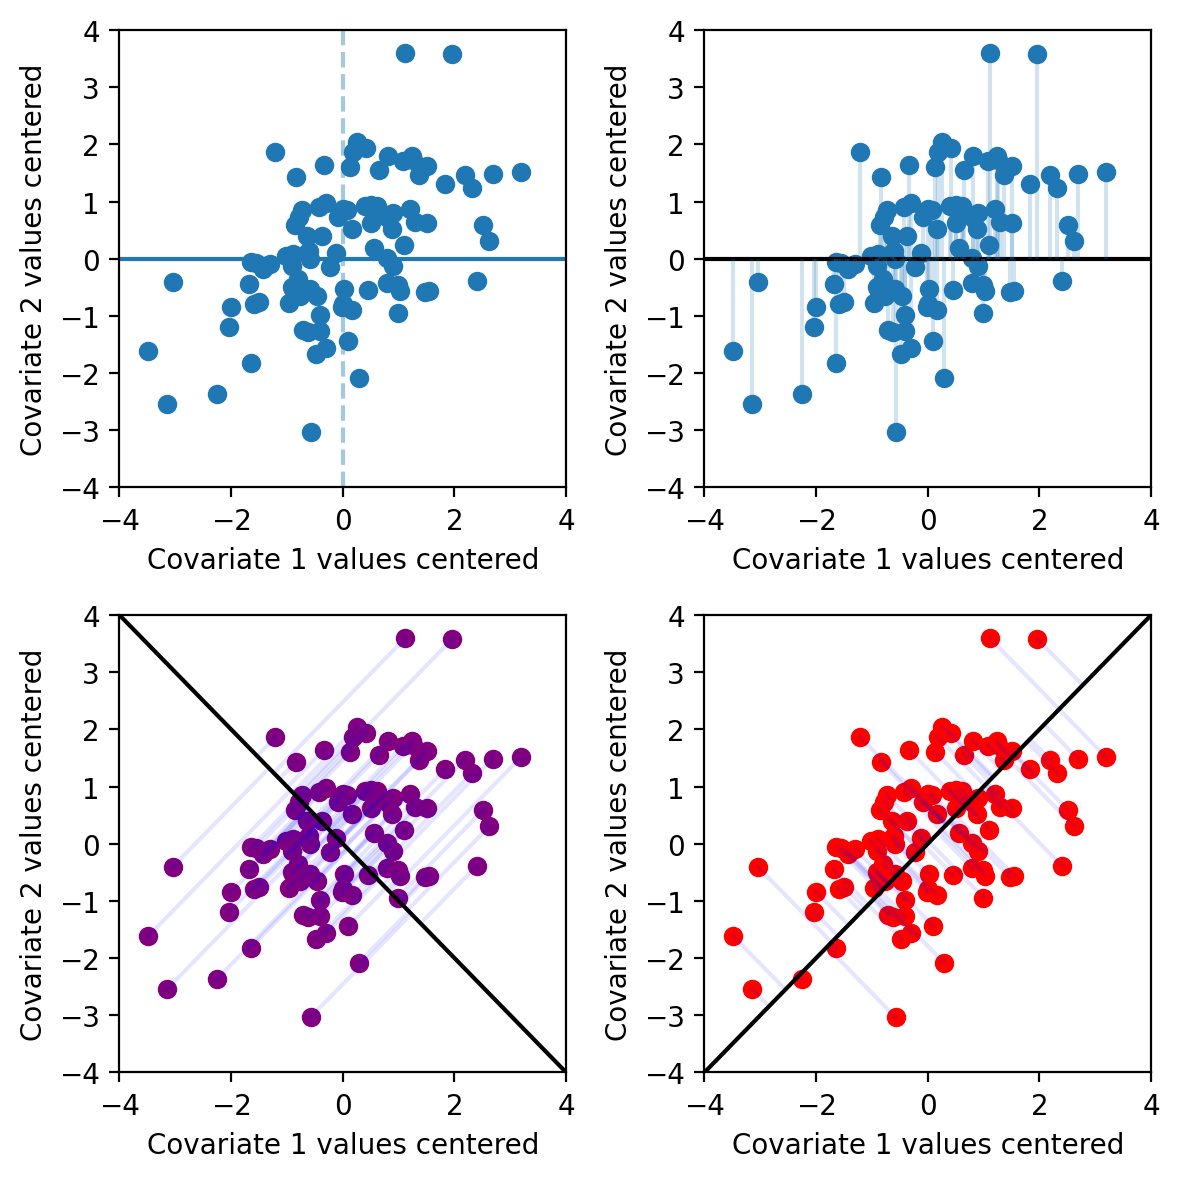

In [20]:
fig,axs = plt.subplots(2,2)

ax=axs[0,0]
ax.scatter(d_centered[:,0], d_centered[:,1])

ax.axhline(0)
ax.axvline(0,ls="--",alpha=0.4)

ax.set_xlabel("Covariate 1 values centered")
ax.set_ylabel("Covariate 2 values centered")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)


ax=axs[0,1]

ax.scatter(d_centered[:,0], d_centered[:,1])
ax.axhline(0,color="black")
ax.vlines(x=d_centered[:,0], ymin=0, ymax=d_centered[:,1],alpha=0.2)
ax.set_xlabel("Covariate 1 values centered")
ax.set_ylabel("Covariate 2 values centered")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)


ax=axs[1,0]
u      = np.array([-1,1]).reshape(2,1)
u      = u/np.linalg.norm(u)

alphas = (d_centered @ u) #<-- N X 1

for point,alpha in zip(d_centered, alphas):
    alpha = float(alpha)
    u0    = float(u[0])
    u1    = float(u[1])
    ax.plot( [alpha*u0, point[0] ] ,  [alpha*u1, point[1]  ], color="blue", alpha=0.1  )
    ax.scatter( point[0], point[1], color ="purple" )
    
ax.plot( [-4,4], [4,-4], color="black" )  
ax.set_xlabel("Covariate 1 values centered")
ax.set_ylabel("Covariate 2 values centered")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)



ax=axs[1,1]
u      = np.array([1,1]).reshape(2,1)
u      = u/np.linalg.norm(u)

alphas = (d_centered @ u) #<-- N X 1

for point,alpha in zip(d_centered, alphas):
    alpha = float(alpha)
    u0    = float(u[0])
    u1    = float(u[1])
    ax.plot( [alpha*u0, point[0] ] ,  [alpha*u1, point[1]  ], color="blue", alpha=0.1  )
    ax.scatter( point[0], point[1], color ="red" )
    
ax.plot( [-4,4], [-4,4], color="black" )  
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

ax.set_xlabel("Covariate 1 values centered")
ax.set_ylabel("Covariate 2 values centered")

fig.set_tight_layout(True)
fig.set_size_inches(6,6)

plt.show()

1.6603550046604607
1.6608182655989445


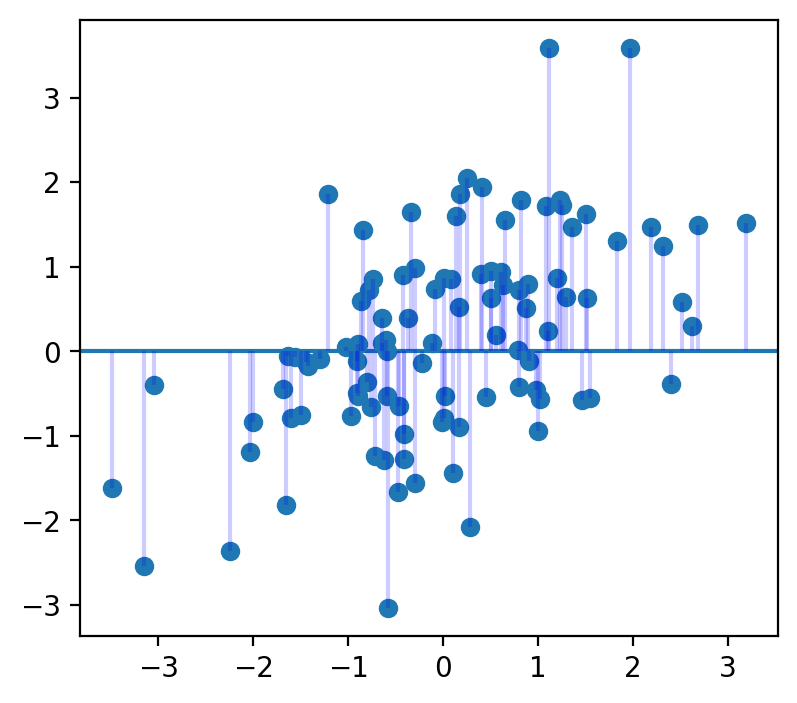

In [4]:
N = len(d_centered)

Var_hline1 = np.var( d_centered[:,0]  )
Var_hline2 = (1/N)*d_centered[:,0].T@d_centered[:,0].T

print(Var_hline1)
print(Var_hline2)

fig,ax = plt.subplots()
ax.scatter(d_centered[:,0], d_centered[:,1])
ax.axhline(0)
ax.vlines(x=d_centered[:,0], ymin=0, ymax=d_centered[:,1], colors='blue',alpha=0.2)

fig.set_size_inches(9/2,4)
plt.show()



In [5]:

l,u         = np.linalg.eigh(COV)
l_est,u_est = np.linalg.eigh( d_centered.T @ d_centered/N )



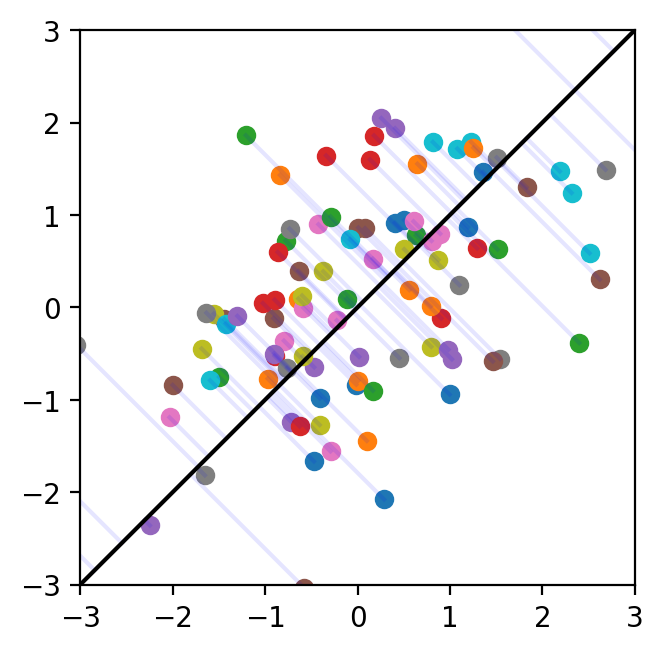

In [6]:

u      = np.array([1,1]).reshape(2,1)
u      = u/np.linalg.norm(u)

alphas = (d_centered @ u) #<-- N X 1

fig, ax = plt.subplots()

for point,alpha in zip(d_centered, alphas):
    alpha = float(alpha)
    u0    = float(u[0])
    u1    = float(u[1])
    ax.plot( [alpha*u0, point[0] ] ,  [alpha*u1, point[1]  ], color="blue", alpha=0.1  )
    ax.scatter( point[0], point[1] )
    
ax.plot( [-3,3], [-3,3], color="black" )  

ax.set_aspect("equal")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.show()

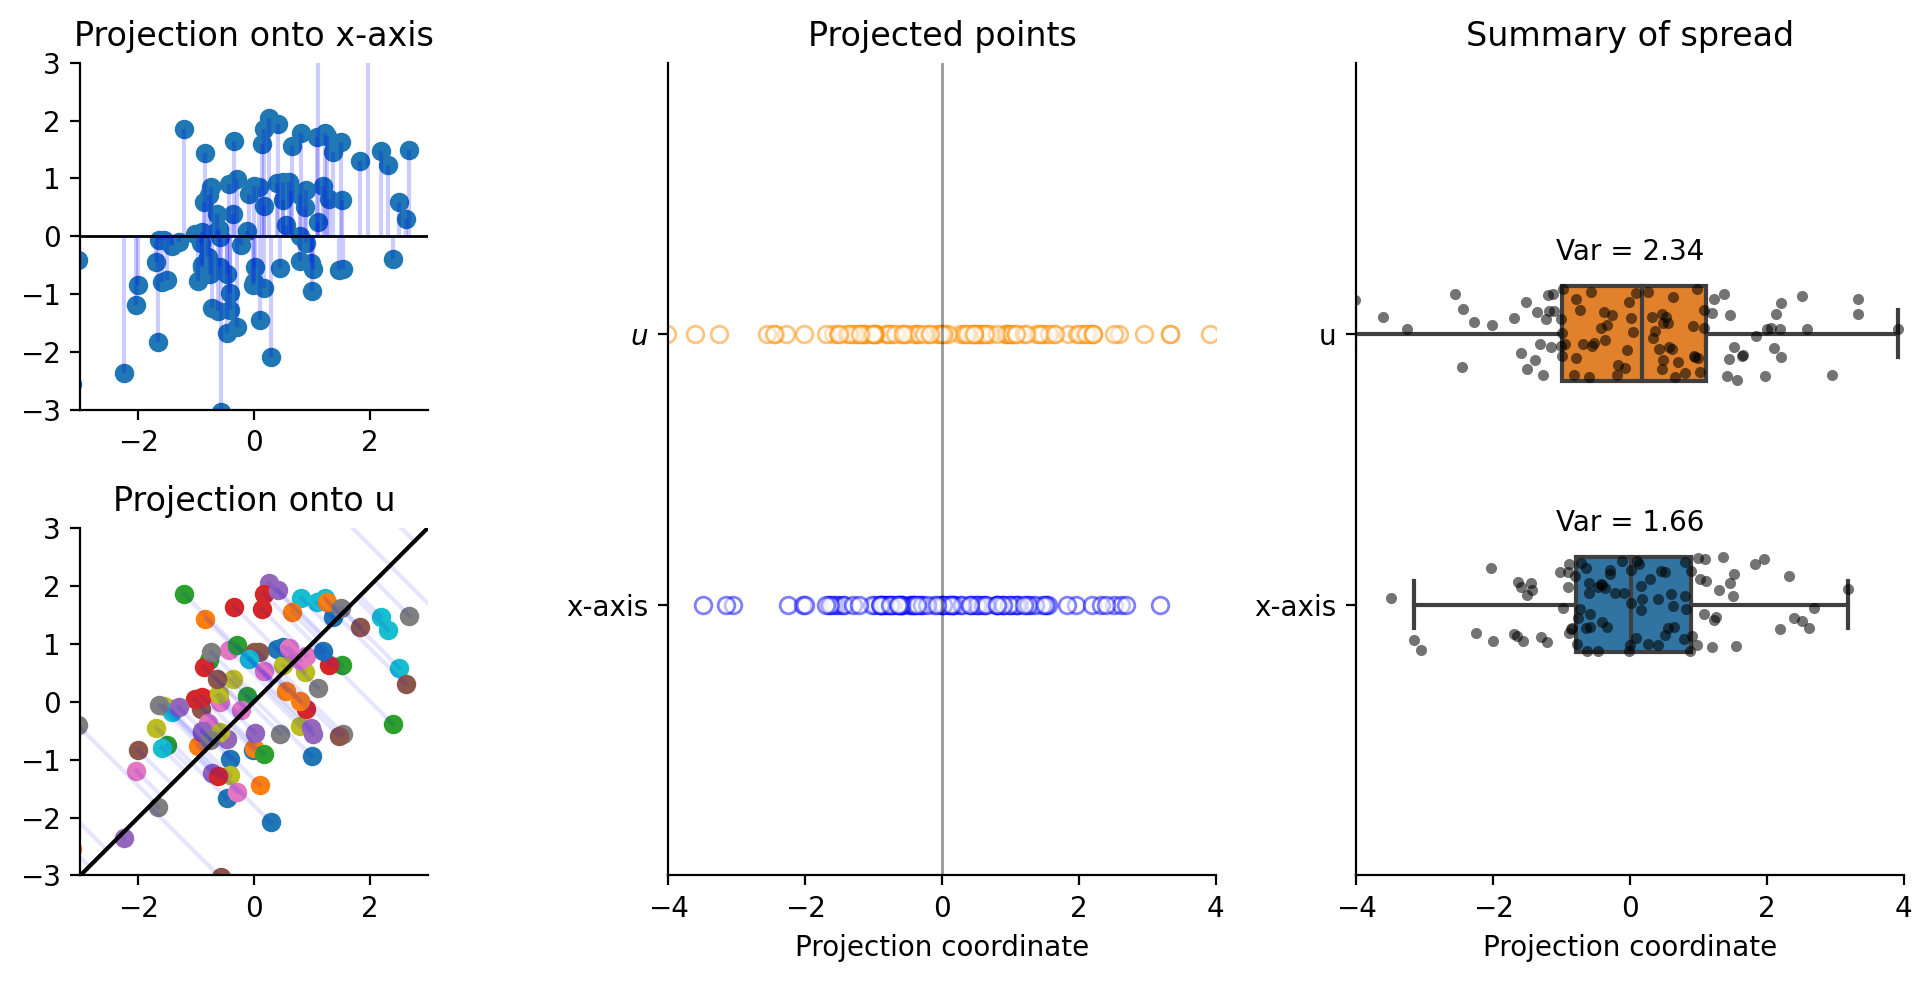

In [7]:
fig = plt.figure(figsize=(10, 5))
gs  = fig.add_gridspec(2, 3)

ax00 = fig.add_subplot(gs[0, 0])
ax10 = fig.add_subplot(gs[1, 0])

ax_proj = fig.add_subplot(gs[:, 1])  # joined second column
ax_box  = fig.add_subplot(gs[:, 2])  # joined third column

# ------------------------------------------------------------
# First row, first column: original data + projection to x-axis
# ------------------------------------------------------------
ax = ax00
ax.scatter(d_centered[:, 0], d_centered[:, 1])
ax.axhline(0, color="black", linewidth=1)
ax.vlines(x=d_centered[:, 0], ymin=0, ymax=d_centered[:, 1],colors="blue",alpha=0.2)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title("Projection onto x-axis")

# ------------------------------------------------------------
# Second row, first column: original data + projection to u
# ------------------------------------------------------------
u = np.array([1, 1], dtype=float).reshape(2, 1)
u = u / np.linalg.norm(u)

alphas = d_centered @ u          # N x 1
projs  = alphas @ u.T            # N x 2

ax = ax10
for point, proj in zip(d_centered, projs):
    ax.plot([proj[0], point[0]],[proj[1], point[1]],color="blue",alpha=0.1,)
    ax.scatter(point[0], point[1])

ax.plot([-3, 3], [-3, 3], color="black")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title(r"Projection onto u")

# ------------------------------------------------------------
# Joined second column: compare 1D projected coordinates
# ------------------------------------------------------------
x_proj = d_centered[:, 0]
u_proj = alphas.reshape(-1)

ax = ax_proj

ax.scatter(x_proj
           ,np.zeros_like(x_proj)
           ,facecolor="white",edgecolor="blue",alpha=0.5,label="x-axis")

ax.scatter(u_proj ,np.ones_like(u_proj) ,facecolor="white",edgecolor="darkorange",alpha=0.5,label="u")

ax.set_xlim(-4, 4)
ax.set_ylim(-1, 2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["x-axis", r"$u$"])
ax.axvline(0, color="black", linewidth=1, alpha=0.4)
ax.set_xlabel("Projection coordinate")
ax.set_title("Projected points")

# ------------------------------------------------------------
projected_data = pd.DataFrame({
    "p": np.concatenate([x_proj, u_proj]),
    "projection": ( ["x-axis"] * len(x_proj) + ["u"] * len(u_proj) )})

ax = ax_box

sns.boxplot(x="p"
    ,y="projection"
    ,data=projected_data
    ,ax=ax
    ,width=0.35
    ,showcaps=True
    ,showfliers=False
    #,boxprops={"facecolor": "none", "edgecolor": "black", "linewidth": 1.5}
    #,whiskerprops={"color": "black", "linewidth": 1.2}
    #,capprops={"color": "black", "linewidth": 1.2}
    #,medianprops={"color": "black", "linewidth": 2}
)

sns.stripplot(x="p",y="projection",data=projected_data,ax=ax,jitter=0.18,size=4,alpha=0.55,color="black")

var_xaxis = np.var( x_proj )
var_proj  = np.var( u_proj )

ax.text( 0,1.25, s= "Var = {:.2f}".format(var_proj), va="bottom", ha="center" )
ax.text( 0,0.25, s= "Var = {:.2f}".format(var_xaxis), va="bottom", ha="center" )

ax.set_xlim(-4, 4)
ax.set_ylim(-1,2)
ax.set_xlabel("Projection coordinate")
ax.set_ylabel("")
ax.set_title("Summary of spread")

sns.despine(fig=fig)

plt.tight_layout()
plt.show()

In [8]:
np.var( d_centered[:,0] ) 

1.6603550046604607

In [9]:
np.var(alphas)

2.340793582932784